In [37]:
import tensorflow as tf
from tensorflow.keras import models, layers,optimizers
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2

In [38]:
print(tf.__version__)

2.16.2


In [71]:
IMAGE_SIZE_1 = 224
IMAGE_SIZE_2 = 224
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [40]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "farm",
    shuffle = True,
    image_size = (IMAGE_SIZE_1,IMAGE_SIZE_2),
    batch_size = BATCH_SIZE
)

Found 3000 files belonging to 3 classes.


In [41]:
class_names = dataset.class_names
class_names

['c0', 'c6', 'c9']

In [42]:
len(dataset)

94

2025-05-28 01:04:47.821662: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


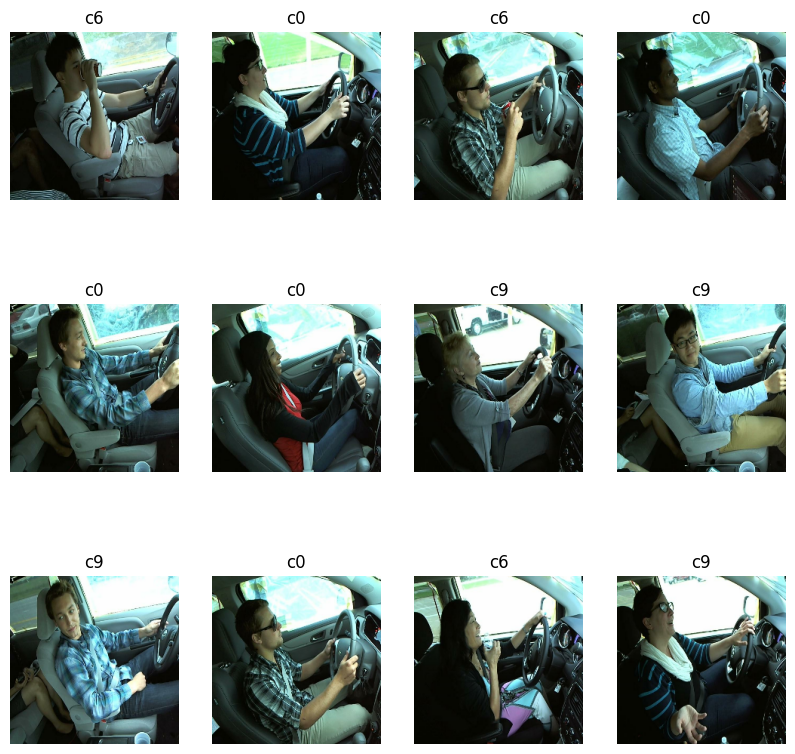

In [43]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.axis("off")
        plt.title(class_names[label_batch[i]])

In [44]:
len(dataset)

94

In [45]:
train_size=0.8
len(dataset)*train_size

75.2

In [46]:
train_ds = dataset.take(173)
len(train_ds)

94

In [47]:
test_ds = dataset.skip(173)
len(test_ds)

0

In [48]:
val_size = 0.1
len(dataset)*val_size

9.4

In [49]:
val_ds = test_ds.take(21)
len(val_ds)

0

In [50]:
test_ds = test_ds.skip(21)
len(test_ds)

0

In [51]:
def get_dataset_partitions_tf(ds,train_split = 0.8 ,val_split = 0.1,test_split = 0.1 , shuffle=True,shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size,seed=12)
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds

In [52]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [53]:
len(train_ds)

75

In [54]:
len(test_ds)

10

In [55]:
len(val_ds)

9

In [56]:
train_ds=train_ds.cache().shuffle(10000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(10000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(10000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [57]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE_1,IMAGE_SIZE_2),
    layers.Rescaling(1.0/255)
])

In [58]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [64]:
input_shape = (IMAGE_SIZE_1,IMAGE_SIZE_2,CHANNELS)
n_classes = 3

# model = models.Sequential([
#     resize_and_rescale,
#     data_augmentation,
#     layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64,(3,3),activation='relu',input_shape=input_shape),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64,(3,3),activation='relu',input_shape=input_shape),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(128,(3,3),activation='relu',input_shape=input_shape),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(128,(3,3),activation='relu',input_shape=input_shape),
#     layers.MaxPooling2D((2,2)),
#     layers.Flatten(),
#     layers.Dense(512,activation='relu'),
#     layers.Dense(n_classes,activation='softmax'),
# ])

input_shape = (IMAGE_SIZE_1,IMAGE_SIZE_2,CHANNELS)
n_classes = 3 # Assuming n_classes is the same as num_classes

def build_mobilenet_model(input_shape, num_classes):
    base_model = MobileNetV2(input_shape=input_shape,
                             include_top=False,
                             weights='imagenet')
    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x) # Converts feature maps to a single vector per image
    x = layers.Dense(128, activation='relu')(x) # A dense layer with 128 neurons
    x = layers.Dropout(0.3)(x) # Dropout for regularization
    predictions = layers.Dense(num_classes, activation='softmax')(x) # Output layer

    # 4. Combine the base model and the new head into a full model
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # 5. Compile the model
    # For the initial training phase, we compile with a standard learning rate.
    # 'sparse_categorical_crossentropy' is suitable if your labels are integers (e.g., 0, 1, 2...).
    # If your labels are one-hot encoded (e.g., [0,0,1]), use 'categorical_crossentropy'.
    # For binary classification, use 'binary_crossentropy'.
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model, base_model

def fine_tune_mobilenet_model(model, base_model, fine_tune_at_layer=None):
    base_model.trainable = True
    if fine_tune_at_layer is None:
        fine_tune_at_layer = 100 # Default to layer 100 if not specified
    
    # Freeze all layers up to fine_tune_at_layer
    for layer in base_model.layers[:fine_tune_at_layer]:
        layer.trainable = False
    
    print(f"\nRe-compiling model for fine-tuning from layer {fine_tune_at_layer}...")
    model.compile(optimizer=optimizers.Adam(learning_rate=0.00001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Example Usage:
# Assuming 'num_classes' is defined as n_classes earlier in your code
num_classes = n_classes 

# Build the initial model
model, base_model = build_mobilenet_model(input_shape, num_classes)
model.summary()

# Fine-tune the model (example: fine-tune from layer 120)
fine_tuned_model = fine_tune_mobilenet_model(model, base_model, fine_tune_at_layer=120)
fine_tuned_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

...

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 1,789,251 (6.83 MB)

 Non-trainable params: 633,088 (2.42 MB)

In [65]:
# model.summary()

In [66]:
# model.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
#     metrics=['accuracy']
# )

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', # Or 'categorical_crossentropy' or 'binary_crossentropy'
              metrics=['accuracy'])

In [67]:
model.compile(optimizer=optimizers.Adam(learning_rate=0.00001), # CRUCIAL: Much lower learning rate
              loss='sparse_categorical_crossentropy', # Must match the loss from initial compile
              metrics=['accuracy'])

In [72]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds,
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.9747 - loss: 0.1091 - val_accuracy: 0.5451 - val_loss: 0.9335
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 185ms/step - accuracy: 0.9818 - loss: 0.0935 - val_accuracy: 0.5764 - val_loss: 0.8960
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 189ms/step - accuracy: 0.9846 - loss: 0.0761 - val_accuracy: 0.5764 - val_loss: 0.8758
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 187ms/step - accuracy: 0.9943 - loss: 0.0569 - val_accuracy: 0.6111 - val_loss: 0.8466
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 184ms/step - accuracy: 0.9954 - loss: 0.0512 - val_accuracy: 0.6215 - val_loss: 0.8843
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 186ms/step - accuracy: 0.9967 - loss: 0.0456 - val_accuracy: 0.6528 - val_loss: 0.8331
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 189ms/step - accuracy: 0.9984 - loss: 0.0396 - val_accuracy: 0.6597 - val_loss: 0.8398
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - accuracy: 0.9987 - loss: 0.0316 - val_accu

In [73]:
scores = model.evaluate(test_ds)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.9932 - loss: 0.0221


In [74]:
scores

[0.021485263481736183, 0.9937499761581421]

In [75]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 75}

In [76]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [77]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

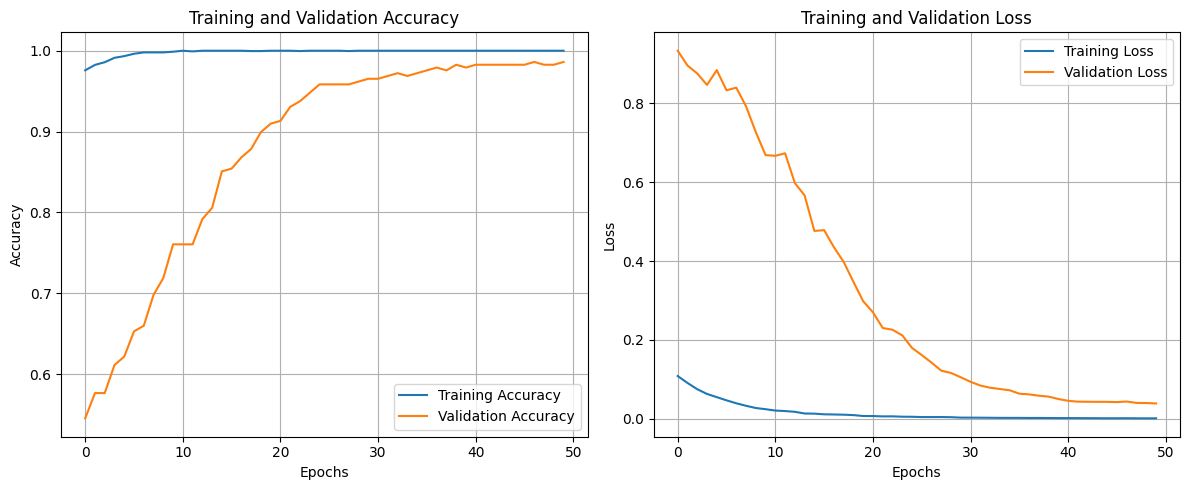

In [78]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # Required for tf.data.Dataset operations

# --- IMPORTANT: Ensure these variables are defined in your environment ---
# model: Your trained Keras model (e.g., the 'full_model' from previous steps)
# test_ds: Your TensorFlow Dataset for testing.
#          Ensure it's batched and ready for prediction.
# class_names: A list of strings mapping class indices to human-readable names.
#              Example: class_names = ['airplane', 'automobile', 'bird', ...]

# Example placeholder for class_names if not already defined.
# YOU MUST REPLACE THIS WITH YOUR ACTUAL CLASS NAMES
if 'class_names' not in locals():
    print("WARNING: 'class_names' not found. Using placeholder names.")
    # Replace with your actual class names
    class_names = [f"Class {i}" for i in range(NUM_CLASSES if 'NUM_CLASSES' in locals() else 10)]


def display_random_predictions(model, test_ds, class_names, num_images=9):
    """
    Takes a batch from the test dataset, makes predictions, and displays
    a specified number of images with their actual and predicted labels.

    Args:
        model (tf.keras.Model): The trained Keras model.
        test_ds (tf.data.Dataset): The TensorFlow Dataset containing test images and labels.
                                   It should be batched.
        class_names (list): A list of strings, where index i corresponds to the name of class i.
        num_images (int): The number of random images to display (e.g., 9 for a 3x3 grid).
    """
    # Get one batch of images and labels from the test dataset.
    # .take(1) gets the first batch. .as_numpy_iterator() converts it to a NumPy iterator.
    # next(...) retrieves the actual batch (images, labels).
    # Ensure your test_ds is batched with a size at least `num_images`.
    try:
        images_batch, labels_batch = next(iter(test_ds.take(1)))
    except StopIteration:
        print("Error: test_ds is empty or cannot yield a batch.")
        return

    # Ensure we don't try to display more images than are in the batch
    if num_images > images_batch.shape[0]:
        print(f"Warning: Requested {num_images} images, but batch only contains {images_batch.shape[0]}. Displaying all available.")
        num_images = images_batch.shape[0]

    # Make predictions for the entire batch
    batch_predictions = model.predict(images_batch)

    # Set up the plot for a grid of images
    # Calculate grid dimensions (e.g., 3x3 for 9 images)
    grid_size = int(np.ceil(np.sqrt(num_images)))
    plt.figure(figsize=(grid_size * 3, grid_size * 3)) # Adjust figure size for better visualization
    plt.suptitle("Actual vs. Predicted Labels", fontsize=16)

    for i in range(num_images):
        # Select the i-th image, convert to NumPy array and ensure uint8 type for display
        image_to_display = images_batch[i].numpy().astype("uint8")
        actual_label = labels_batch[i].numpy()
        predicted_probabilities = batch_predictions[i]
        predicted_label = np.argmax(predicted_probabilities)

        # Create subplot
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(image_to_display)
        plt.axis('off') # Hide axes for cleaner image display

        # Set title with actual and predicted labels
        color = "green" if actual_label == predicted_label else "red"
        title_text = f"Actual: {class_names[actual_label]}\nPred: {class_names[predicted_label]}"
        plt.title(title_text, color=color, fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# --- How to use the function ---
# Assuming 'model', 'test_ds', and 'class_names' are already defined from your training script.
# Example call:
# display_random_predictions(model, test_ds, class_names, num_images=9)

print("Function 'display_random_predictions' defined.")
print("To use it, ensure 'model', 'test_ds', and 'class_names' are available in your environment,")
print("then call: `display_random_predictions(model, test_ds, class_names, num_images=9)`")
print("Remember to adjust `class_names` if the placeholder is active.")


Function 'display_random_predictions' defined.
To use it, ensure 'model', 'test_ds', and 'class_names' are available in your environment,
then call: `display_random_predictions(model, test_ds, class_names, num_images=9)`
Remember to adjust `class_names` if the placeholder is active.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


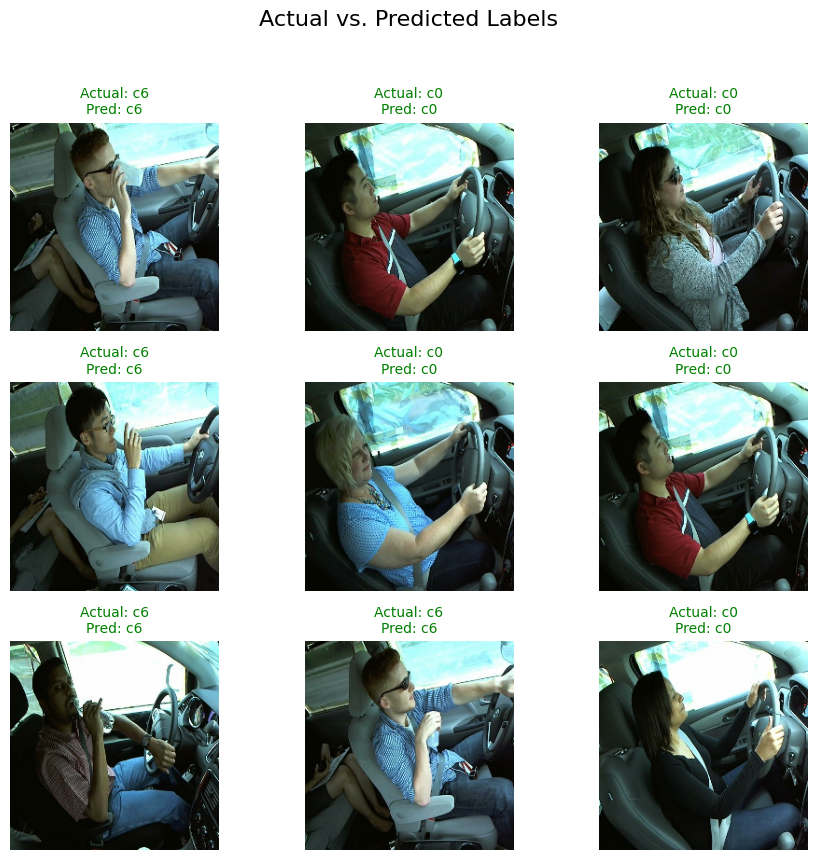

In [94]:
display_random_predictions(model, test_ds, class_names, num_images=9)

In [97]:
model_version = 1
save_path = f"models/{model_version}.keras"
model.save(save_path)
print(f"Model saved to {save_path}")

Model saved to models/1.keras
